<a href="https://colab.research.google.com/github/pald22/STAT-4830-NAPPERS-project/blob/main/demo_01_standalone_optimization_equity_and_polymarket.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Standalone Demo 1 — Equity and Polymarket optimization

This notebook is self-contained: it does **not** import any project source files or scripts. All helper functions used by the equity optimizer and the Polymarket mispricing optimizer are embedded below.

External inputs are limited to two checked-in datasets:

1. `sp500_monthly (1) (1).csv` for the equity rolling optimizer.
2. `polymarket_daily_panel_60plus.csv` for the Polymarket mispricing optimizer.

The notebook writes optional result artifacts under `Outputs/standalone_demo_optimization/`, but it does not read any helper code or precomputed output files.

In [ ]:

from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
from typing import Any
import json
import math
import os
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import accuracy_score, brier_score_loss, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)
np.random.seed(42)


def find_data_file(filename: str, known_dirs: tuple[str, ...]) -> Path:
    """Locate a project dataset without importing any project package.

    The notebook is meant to run from the repository root, from notebooks/, or
    from a folder containing the two CSV datasets. Optional environment variable
    NAPPERS_DATA_DIR may point to a directory containing the data files.
    """
    roots: list[Path] = []
    env = os.environ.get("NAPPERS_DATA_DIR")
    if env:
        roots.append(Path(env).expanduser().resolve())
    cwd = Path.cwd().resolve()
    roots.extend([cwd, *cwd.parents])

    candidates: list[Path] = []
    seen: set[str] = set()
    for root in roots:
        for rel_dir in ("", *known_dirs):
            path = root / rel_dir / filename if rel_dir else root / filename
            key = str(path)
            if key not in seen:
                seen.add(key)
                candidates.append(path)

    for path in candidates:
        if path.is_file():
            return path

    msg = "Could not find dataset {0}. Checked:\n".format(filename)
    msg += "\n".join("  - " + str(p) for p in candidates[:40])
    raise FileNotFoundError(msg)


def infer_project_root_from_data(*paths: Path) -> Path:
    """Use the dataset location to choose an output directory root."""
    for path in paths:
        for parent in path.resolve().parents:
            if (parent / "data").is_dir():
                return parent
    return Path.cwd().resolve()

EQUITY_CSV = find_data_file("sp500_monthly (1) (1).csv", ("data/stock_market", "stock_market", "data"))
POLY_PANEL_CSV = find_data_file("polymarket_daily_panel_60plus.csv", ("data/prediction_market", "prediction_market", "data"))

print("Equity dataset:", EQUITY_CSV)
print("Polymarket dataset:", POLY_PANEL_CSV)


Equity dataset: /content/sp500_monthly (1) (1).csv
Polymarket dataset: /content/polymarket_daily_panel_60plus.csv


## Function block A — equity optimizer

This block embeds the rolling moment estimator, simplex projection, projected-subgradient optimizer, and walk-forward equity backtest. The objective is

$$
\max_w \mu_t^\top w - \gamma w^\top \Sigma_t w - \kappa \lVert w-w_{t-1}\rVert_1,\quad w\ge 0,\quad \sum_i w_i=1.
$$

In [ ]:

# -----------------------------
# Standalone equity optimizer
# -----------------------------

def estimate_moments(window_returns: pd.DataFrame, ridge: float = 1e-6) -> tuple[np.ndarray, np.ndarray]:
    """Estimate rolling mean returns and a ridge-stabilized covariance matrix."""
    if window_returns.empty:
        raise ValueError("window_returns must contain at least one row and one asset")
    clean = window_returns.apply(pd.to_numeric, errors="coerce").dropna(axis=1, how="all")
    if clean.shape[1] == 0:
        raise ValueError("window_returns has no numeric asset columns after cleaning")
    col_means = clean.mean(axis=0)
    clean = clean.fillna(col_means).fillna(0.0)
    mu = clean.mean(axis=0).to_numpy(dtype=float)
    Sigma = clean.cov().to_numpy(dtype=float)
    if Sigma.ndim == 0:
        Sigma = np.array([[float(Sigma)]], dtype=float)
    Sigma = np.nan_to_num(Sigma, nan=0.0, posinf=0.0, neginf=0.0)
    Sigma = 0.5 * (Sigma + Sigma.T) + float(ridge) * np.eye(Sigma.shape[0])
    return mu, Sigma


def project_to_simplex(v: np.ndarray) -> np.ndarray:
    """Euclidean projection onto {w: w >= 0, sum(w) = 1}."""
    v = np.asarray(v, dtype=float)
    if v.ndim != 1:
        raise ValueError("simplex projection expects a one-dimensional vector")
    n = v.size
    if n == 0:
        raise ValueError("cannot project an empty vector")
    u = np.sort(v)[::-1]
    cssv = np.cumsum(u)
    active = u * np.arange(1, n + 1) > (cssv - 1.0)
    if not np.any(active):
        return np.ones(n, dtype=float) / n
    rho = np.nonzero(active)[0][-1]
    theta = (cssv[rho] - 1.0) / float(rho + 1)
    w = np.maximum(v - theta, 0.0)
    total = w.sum()
    return w / total if total > 0 else np.ones(n, dtype=float) / n


def optimize_weights(
    mu: np.ndarray,
    Sigma: np.ndarray,
    w_prev: np.ndarray | None = None,
    gamma: float = 5.0,
    kappa: float = 0.1,
    steps: int = 200,
    lr: float = 0.1,
) -> np.ndarray:
    """Projected-subgradient solution of the long-only rolling portfolio objective.

    max_w mu'w - gamma * w'Sigma w - kappa * ||w - w_prev||_1
    subject to w >= 0 and sum(w) = 1.
    """
    mu = np.asarray(mu, dtype=float)
    Sigma = np.asarray(Sigma, dtype=float)
    if mu.ndim != 1:
        raise ValueError("mu must be a one-dimensional array")
    n = mu.shape[0]
    if Sigma.shape != (n, n):
        raise ValueError(f"Sigma must have shape {(n, n)}, got {Sigma.shape}")

    if w_prev is None:
        w_prev_np = np.ones(n, dtype=float) / n
    else:
        w_prev_np = np.asarray(w_prev, dtype=float)
        if w_prev_np.shape != (n,):
            raise ValueError(f"w_prev must have shape {(n,)}, got {w_prev_np.shape}")
        w_prev_np = np.clip(np.nan_to_num(w_prev_np, nan=0.0), 0.0, None)
        total = w_prev_np.sum()
        w_prev_np = w_prev_np / total if total > 0 else np.ones(n, dtype=float) / n

    Sigma = np.nan_to_num(0.5 * (Sigma + Sigma.T), nan=0.0, posinf=0.0, neginf=0.0)
    mu = np.nan_to_num(mu, nan=0.0, posinf=0.0, neginf=0.0)
    w = w_prev_np.copy()
    spectral_scale = float(np.linalg.norm(Sigma, ord=2)) if n <= 300 else float(np.linalg.norm(Sigma, ord="fro"))
    base_eta = float(lr) / (1.0 + 2.0 * float(gamma) * spectral_scale)
    base_eta = max(min(base_eta, 1.0), 1e-6)

    for it in range(max(int(steps), 1)):
        d = w - w_prev_np
        subgrad_l1 = np.zeros_like(w)
        mask = np.abs(d) > 1e-10
        subgrad_l1[mask] = np.sign(d[mask])
        grad = mu - 2.0 * float(gamma) * (Sigma @ w) - float(kappa) * subgrad_l1
        eta = base_eta / np.sqrt(it + 1.0)
        w = project_to_simplex(w + eta * grad)
    return project_to_simplex(w)


def align_previous_weights(current_assets: list, w_prev_dict: dict | None) -> np.ndarray:
    if w_prev_dict is None:
        return np.ones(len(current_assets)) / len(current_assets)
    w = np.array([w_prev_dict.get(asset, 0.0) for asset in current_assets], dtype=float)
    return w / w.sum() if w.sum() > 0 else np.ones(len(current_assets)) / len(current_assets)


def performance_metrics(returns: np.ndarray, freq: int = 12) -> dict[str, float]:
    returns = np.asarray(returns, dtype=float)
    if len(returns) == 0:
        return {"mean_period": np.nan, "vol_annual": np.nan, "sharpe_annual": np.nan, "max_drawdown": np.nan, "cum_return": np.nan}
    equity = np.cumprod(1.0 + returns)
    running_max = np.maximum.accumulate(equity)
    drawdown = equity / running_max - 1.0
    std = returns.std(ddof=1) if len(returns) > 1 else np.nan
    return {
        "mean_period": float(returns.mean()),
        "vol_annual": float(std * np.sqrt(freq)) if std and not np.isnan(std) else np.nan,
        "sharpe_annual": float(np.sqrt(freq) * returns.mean() / std) if std and std > 0 else np.nan,
        "max_drawdown": float(drawdown.min()),
        "cum_return": float(equity[-1] - 1.0),
    }


def run_equity_backtest(
    ret_panel: pd.DataFrame,
    mcap_panel: pd.DataFrame,
    rolling_window: int = 24,
    min_history: int = 36,
    k_universe: int = 60,
    months_to_run: int = 96,
    gamma: float = 5.0,
    kappa: float = 0.10,
    steps: int = 80,
    lr: float = 0.08,
) -> dict[str, Any]:
    dates = list(ret_panel.index)
    start_idx = max(rolling_window + min_history, len(dates) - months_to_run)
    hist_count = ret_panel.notna().rolling(min_history).sum().shift(1)

    port_returns: list[float] = []
    bench_returns: list[float] = []
    bt_dates: list[pd.Timestamp] = []
    turnovers: list[float] = []
    weight_history: list[tuple[pd.Timestamp, list, np.ndarray]] = []
    w_prev_dict: dict | None = None

    for t_idx in range(start_idx, len(dates) - 1):
        date_t, date_next = dates[t_idx], dates[t_idx + 1]
        eligible = hist_count.loc[date_t]
        eligible = eligible[eligible >= min_history].index
        mcap_t = mcap_panel.loc[date_t, eligible].dropna().sort_values(ascending=False)
        current_assets = list(mcap_t.head(k_universe).index)
        if len(current_assets) < 5:
            continue

        window = ret_panel.loc[dates[t_idx - rolling_window:t_idx], current_assets]
        valid_assets = list(window.columns[window.notna().all(axis=0)])
        if len(valid_assets) < 5:
            continue
        window = window[valid_assets]
        current_assets = valid_assets

        r_next = ret_panel.loc[date_next, current_assets].fillna(0.0).to_numpy(dtype=float)
        mu, Sigma = estimate_moments(window)
        w_prev = align_previous_weights(current_assets, w_prev_dict)
        w = optimize_weights(mu, Sigma, w_prev=w_prev, gamma=gamma, kappa=kappa, steps=steps, lr=lr)

        port_returns.append(float(w @ r_next))
        bench_returns.append(float(np.mean(r_next)))
        turnovers.append(float(np.abs(w - w_prev).sum()))
        bt_dates.append(date_next)
        weight_history.append((date_t, current_assets, w))
        w_prev_dict = dict(zip(current_assets, w))

    return {
        "dates": pd.DatetimeIndex(bt_dates),
        "portfolio_returns": np.array(port_returns),
        "benchmark_returns": np.array(bench_returns),
        "turnover": np.array(turnovers),
        "weight_history": weight_history,
        "config": {
            "rolling_window": rolling_window,
            "min_history": min_history,
            "k_universe": k_universe,
            "months_to_run": months_to_run,
            "gamma": gamma,
            "kappa": kappa,
            "steps": steps,
            "lr": lr,
        },
    }


## Load the equity dataset and run the rolling optimizer

In [ ]:

df_eq = pd.read_csv(EQUITY_CSV)
df_eq["date"] = pd.to_datetime(df_eq["date"], errors="coerce")
df_eq = df_eq.sort_values(["date", "permno"]).copy()

# CRSP-style common-share/main-exchange filter used in the project notebooks.
if "shrcd" in df_eq.columns:
    df_eq = df_eq[df_eq["shrcd"].isin([10, 11])].copy()
if "exchcd" in df_eq.columns:
    df_eq = df_eq[df_eq["exchcd"].isin([1, 2, 3])].copy()

df_eq["ret"] = pd.to_numeric(df_eq["ret"], errors="coerce")
df_eq["prc"] = pd.to_numeric(df_eq["prc"], errors="coerce").abs()
df_eq["shrout"] = pd.to_numeric(df_eq["shrout"], errors="coerce")
df_eq["mcap"] = df_eq["prc"] * df_eq["shrout"]
df_eq = df_eq.dropna(subset=["date", "permno", "ret"]).copy()

ret_panel = df_eq.pivot_table(index="date", columns="permno", values="ret", aggfunc="first").sort_index()
mcap_panel = df_eq.pivot_table(index="date", columns="permno", values="mcap", aggfunc="first").sort_index()

equity_summary = {
    "rows": len(df_eq),
    "unique_assets": int(df_eq["permno"].nunique()),
    "unique_months": int(df_eq["date"].nunique()),
    "date_min": str(df_eq["date"].min().date()),
    "date_max": str(df_eq["date"].max().date()),
    "return_panel_shape": ret_panel.shape,
}
display(pd.DataFrame([equity_summary]))

eq_result = run_equity_backtest(ret_panel, mcap_panel)
equity_metrics = pd.DataFrame([
    {"strategy": "optimized", **performance_metrics(eq_result["portfolio_returns"]), "avg_turnover": float(eq_result["turnover"].mean())},
    {"strategy": "equal_weight_same_universe", **performance_metrics(eq_result["benchmark_returns"]), "avg_turnover": np.nan},
])
display(equity_metrics.round(4))
print("Backtest months:", len(eq_result["dates"]))
print("Config:", eq_result["config"])


/tmp/ipykernel_7046/2922251827.py:1: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  df_eq = pd.read_csv(EQUITY_CSV)


,rows,unique_assets,unique_months,date_min,date_max,return_panel_shape
0,138772,971,300,2000-01-31,2024-12-31,"(300, 971)"


,strategy,mean_period,vol_annual,sharpe_annual,max_drawdown,cum_return,avg_turnover
0,optimized,0.0117,0.1482,0.9469,-0.1916,1.7718,0.0105
1,equal_weight_same_universe,0.0119,0.1545,0.9248,-0.2369,1.8057,NaN


Backtest months: 95
Config: {'rolling_window': 24, 'min_history': 36, 'k_universe': 60, 'months_to_run': 96, 'gamma': 5.0, 'kappa': 0.1, 'steps': 80, 'lr': 0.08}


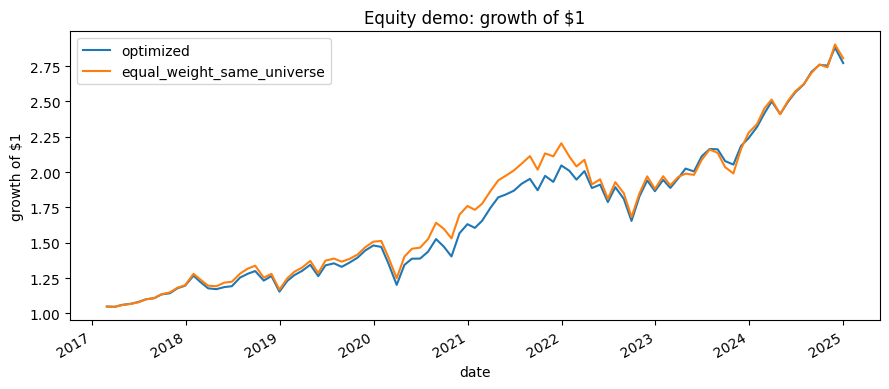

,avg_weight
84788,0.032060
92655,0.030969
13721,0.030384
10107,0.029136
65875,0.028630
50876,0.028527
83443,0.028383
13856,0.027983
66181,0.027534
10145,0.027348


In [ ]:

eq_curve = pd.DataFrame(
    {
        "optimized": np.cumprod(1 + eq_result["portfolio_returns"]),
        "equal_weight_same_universe": np.cumprod(1 + eq_result["benchmark_returns"]),
    },
    index=eq_result["dates"],
)
ax = eq_curve.plot(figsize=(9, 4), title="Equity demo: growth of $1")
ax.set_xlabel("date")
ax.set_ylabel("growth of $1")
plt.tight_layout()
plt.show()

all_assets = sorted({asset for _, assets, _ in eq_result["weight_history"] for asset in assets})
wmat = pd.DataFrame(0.0, index=[d for d, _, _ in eq_result["weight_history"]], columns=all_assets)
for d, assets, w in eq_result["weight_history"]:
    wmat.loc[d, assets] = w
weight_summary = wmat.mean().sort_values(ascending=False).head(10).to_frame("avg_weight")
display(weight_summary)


## Function block B — Polymarket mispricing optimizer

This block embeds the daily-panel normalization, feature construction, Ridge baseline probability model, executable-price approximation, projected-gradient portfolio optimizer, walk-forward loop, and diagnostics. The key Polymarket objective is

$$
F(w)=\sum_i w_i(\hat p_i-c_i)-\gamma\sum_i w_i^2\hat p_i(1-\hat p_i)-\kappa\lVert w-w_{t-1}\rVert_1.
$$

The constraints are long-only gross exposure, per-contract caps, event concentration caps, and an inverse-liquidity budget.

In [ ]:

# -------------------------------------------------------
# Standalone Polymarket mispricing optimization pipeline
# -------------------------------------------------------

def first_outcome_price(raw: Any) -> float:
    if pd.isna(raw) or raw == "":
        return np.nan
    try:
        arr = json.loads(raw)
        return float(arr[0]) if arr else np.nan
    except (json.JSONDecodeError, TypeError, ValueError, IndexError):
        return np.nan


def first_event_id(raw: Any) -> str | float:
    if pd.isna(raw) or raw == "":
        return np.nan
    try:
        evs = json.loads(raw)
        if not evs:
            return np.nan
        return str(evs[0].get("id", np.nan))
    except (json.JSONDecodeError, TypeError, AttributeError):
        return np.nan


def first_event_slug(raw: Any) -> str | float:
    if pd.isna(raw) or raw == "":
        return np.nan
    try:
        evs = json.loads(raw)
        if not evs:
            return np.nan
        return str(evs[0].get("slug", np.nan))
    except (json.JSONDecodeError, TypeError, AttributeError):
        return np.nan


def enrich_snapshot(df: pd.DataFrame) -> pd.DataFrame:
    """Normalize snapshot/daily-panel columns used by the optimizer."""
    out = df.copy()
    if "id" not in out.columns and "market_id" in out.columns:
        out["id"] = out["market_id"]
    if "outcomePrices" in out.columns:
        out["implied_0"] = out["outcomePrices"].map(first_outcome_price)
    if "implied_0" not in out.columns and "price" in out.columns:
        out["implied_0"] = pd.to_numeric(out["price"], errors="coerce")
    if "price" in out.columns and "market_id" in out.columns and ("date" in out.columns or "datetime_utc" in out.columns):
        out["implied_0"] = pd.to_numeric(out["price"], errors="coerce")
    if "events" in out.columns:
        out["event_id"] = out["events"].map(first_event_id)
        out["event_slug"] = out["events"].map(first_event_slug)
    elif "slug" in out.columns:
        out["event_id"] = out["slug"].astype(str)
        out["event_slug"] = out["slug"].astype(str)
    if "createdAt" in out.columns:
        out["createdAt"] = pd.to_datetime(out["createdAt"], utc=True, errors="coerce")
    elif "datetime_utc" in out.columns:
        out["createdAt"] = pd.to_datetime(out["datetime_utc"], utc=True, errors="coerce")
    elif "date" in out.columns:
        out["createdAt"] = pd.to_datetime(out["date"], utc=True, errors="coerce")
    elif "timestamp" in out.columns:
        out["createdAt"] = pd.to_datetime(out["timestamp"], unit="s", utc=True, errors="coerce")
    if "endDateIso" in out.columns:
        out["endDate_parsed"] = pd.to_datetime(out["endDateIso"], utc=True, errors="coerce")
    elif "end_date_iso" in out.columns:
        out["endDate_parsed"] = pd.to_datetime(out["end_date_iso"], utc=True, errors="coerce")
    elif "endDate" in out.columns:
        out["endDate_parsed"] = pd.to_datetime(out["endDate"], utc=True, errors="coerce")
    return out


def safe_log1p(x: pd.Series) -> pd.Series:
    return np.log1p(pd.to_numeric(x, errors="coerce").clip(lower=0.0))


def build_raw_features(df: pd.DataFrame, ref_time: pd.Timestamp) -> pd.DataFrame:
    feats = pd.DataFrame(index=df.index)
    feats["log_volume"] = safe_log1p(df.get("volumeNum", df.get("volume", pd.Series(0.0, index=df.index))))
    feats["log_liquidity"] = safe_log1p(df.get("liquidityNum", df.get("liquidity", pd.Series(0.0, index=df.index))))
    feats["spread"] = pd.to_numeric(df.get("spread", pd.Series(0.0, index=df.index)), errors="coerce")
    feats["competitive"] = pd.to_numeric(df.get("competitive", pd.Series(0.0, index=df.index)), errors="coerce")
    end = df["endDate_parsed"] if "endDate_parsed" in df.columns else pd.Series(pd.NaT, index=df.index)
    if not isinstance(ref_time, pd.Timestamp):
        ref_time = pd.Timestamp(ref_time)
    if ref_time.tzinfo is None:
        ref_time = ref_time.tz_localize("UTC")
    days = (pd.to_datetime(end, utc=True) - ref_time).dt.total_seconds() / 86400.0
    feats["log_days_to_end"] = np.log1p(np.maximum(days.fillna(30.0), 1.0))
    liq_source = df.get("liquidityNum", df.get("liquidity", pd.Series(1.0, index=df.index)))
    liq = pd.to_numeric(liq_source, errors="coerce").fillna(1.0).clip(lower=1.0)
    feats["neg_log_liquidity"] = -np.log(liq)
    return feats


def fit_transform_features(df_train: pd.DataFrame, df_test: pd.DataFrame | None, ref_time: pd.Timestamp) -> tuple[np.ndarray, StandardScaler, np.ndarray | None]:
    raw_tr = build_raw_features(df_train, ref_time)
    raw_tr = raw_tr.replace([np.inf, -np.inf], np.nan)
    med = raw_tr.median(numeric_only=True).fillna(0.0)
    raw_tr = raw_tr.fillna(med).fillna(0.0)
    scaler = StandardScaler()
    X_train = scaler.fit_transform(raw_tr.values)

    if df_test is None:
        return X_train, scaler, None
    raw_te = build_raw_features(df_test, ref_time=ref_time).replace([np.inf, -np.inf], np.nan)
    raw_te = raw_te.reindex(columns=raw_tr.columns).fillna(med).fillna(0.0)
    X_test = scaler.transform(raw_te.values)
    return X_train, scaler, X_test


def logit(p: np.ndarray, lo: float = 0.02, hi: float = 0.98) -> np.ndarray:
    p = np.clip(p, lo, hi)
    return np.log(p / (1.0 - p))


def fit_ridge_logit_implied(X_train: np.ndarray, implied_train: np.ndarray, alpha: float = 1.0) -> Ridge:
    y = logit(implied_train.astype(float))
    mask = np.isfinite(y) & np.isfinite(X_train).all(axis=1)
    if mask.sum() < 2:
        raise ValueError("Not enough finite training rows for the baseline Ridge model")
    model = Ridge(alpha=alpha, fit_intercept=True)
    model.fit(X_train[mask], y[mask])
    return model


def predict_p_hat(model: Ridge, X: np.ndarray) -> np.ndarray:
    z = model.predict(X)
    p = 1.0 / (1.0 + np.exp(-z))
    return np.clip(p, 0.02, 0.98)


def executable_yes_price(df: pd.DataFrame) -> pd.Series:
    implied_src = df.get("implied_0", df.get("price", pd.Series(np.nan, index=df.index)))
    implied = pd.to_numeric(implied_src, errors="coerce")
    bid = pd.to_numeric(df.get("bestBid", pd.Series(np.nan, index=df.index)), errors="coerce")
    ask = pd.to_numeric(df.get("bestAsk", pd.Series(np.nan, index=df.index)), errors="coerce")
    sp = pd.to_numeric(df.get("spread", pd.Series(np.nan, index=df.index)), errors="coerce")
    out = implied.copy()
    if implied.isna().any() and ask.notna().any():
        out = out.where(~implied.isna(), ask)
    mid = (bid + ask) / 2.0
    use_mid = bid.notna() & ask.notna()
    out = out.where(~use_mid, mid)
    use_ask = ask.notna()
    out = out.where(~use_ask, ask)
    half = sp / 2.0
    fallback = (implied + half).where(implied.notna() & sp.notna(), implied)
    mask = out.isna() & implied.notna()
    out = out.where(~mask, fallback[mask])
    return out.clip(0.001, 0.999)


def liquidity_loadings(df: pd.DataFrame, eps: float = 1.0) -> np.ndarray:
    liq_source = df.get("liquidityNum", df.get("liquidity", pd.Series(1.0, index=df.index)))
    liq = pd.to_numeric(liq_source, errors="coerce").fillna(1.0).values.astype(float)
    liq = np.maximum(liq, eps)
    return 1.0 / np.sqrt(liq)


def subgrad_l1(w: np.ndarray, w_prev: np.ndarray, kappa: float) -> np.ndarray:
    d = w - w_prev
    g = np.zeros_like(w)
    mask = np.abs(d) > 1e-12
    g[mask] = kappa * np.sign(d[mask])
    return g


def smooth_gradient(w: np.ndarray, a: np.ndarray, p_hat: np.ndarray, gamma: float) -> np.ndarray:
    v = p_hat * (1.0 - p_hat)
    return a - 2.0 * gamma * w * v


def unique_event_indices(event_codes: np.ndarray) -> list[np.ndarray]:
    out: list[np.ndarray] = []
    for e in np.unique(event_codes):
        idx = np.flatnonzero(event_codes == e)
        if len(idx) > 1:
            out.append(idx)
    return out


def project_feasible_fast_v2(
    w: np.ndarray,
    w_cap: np.ndarray,
    event_groups: list[np.ndarray],
    w_event_max: float,
    liq_load: np.ndarray,
    liq_budget: float,
    n_passes: int = 50,
) -> np.ndarray:
    w = np.clip(w.astype(float), 0, w_cap)
    for _ in range(n_passes):
        if w.sum() > 1.0 + 1e-12:
            w *= 1.0 / w.sum()
        w = np.clip(w, 0, w_cap)
        for idx in event_groups:
            s = float(w[idx].sum())
            if s > w_event_max + 1e-12:
                w[idx] *= w_event_max / s
        w = np.clip(w, 0, w_cap)
        liq_dot = float(np.dot(liq_load, w))
        if liq_budget < 1e9 and liq_dot > liq_budget + 1e-12:
            w *= liq_budget / (liq_dot + 1e-12)
        w = np.clip(w, 0, w_cap)
    return w


def maximize_portfolio_projected_gradient(
    a: np.ndarray,
    p_hat: np.ndarray,
    w_prev: np.ndarray,
    gamma: float,
    kappa: float,
    w_contract_cap: np.ndarray,
    event_codes: np.ndarray,
    liq_load: np.ndarray,
    w_event_max: float,
    liq_budget: float,
    n_iter: int = 800,
    eta0: float | None = None,
) -> tuple[np.ndarray, np.ndarray]:
    w = np.zeros(len(a))
    v = p_hat * (1.0 - p_hat)
    lip = 2.0 * gamma * (np.max(v) + 1e-8) + 1e-8
    eta = eta0 if eta0 is not None else 0.5 / lip
    event_groups = unique_event_indices(event_codes)
    hist: list[float] = []
    for it in range(n_iter):
        g = smooth_gradient(w, a, p_hat, gamma) - subgrad_l1(w, w_prev, kappa)
        w = project_feasible_fast_v2(w + eta * g, w_contract_cap, event_groups, w_event_max, liq_load, liq_budget)
        smooth_obj = float(np.dot(w, a) - gamma * np.sum((w**2) * v))
        hist.append(smooth_obj)
        if it > 15 and abs(hist[-1] - hist[-2]) < 1e-9 * (abs(hist[-1]) + 1.0):
            break
        eta *= 0.9997
    return w, np.array(hist)


def total_objective(w: np.ndarray, a: np.ndarray, p_hat: np.ndarray, w_prev: np.ndarray, gamma: float, kappa: float) -> float:
    v = p_hat * (1.0 - p_hat)
    smooth = float(np.dot(w, a) - gamma * np.sum((w**2) * v))
    pen = kappa * float(np.sum(np.abs(w - w_prev)))
    return smooth - pen


@dataclass
class MispricingConfig:
    n_folds: int = 5
    min_train_rows: int = 30
    ridge_alpha: float = 5.0
    gamma: float = 2.0
    kappa: float = 0.05
    w_contract_max: float = 0.08
    w_event_max: float = 0.25
    liq_budget: float = 2.5
    rng_seed: int = 42
    n_opt_iter: int = 800
    train_ratio: float = 0.6
    valid_ratio: float = 0.2


def assign_time_folds(df: pd.DataFrame, n_folds: int) -> pd.Series:
    if "createdAt" not in df.columns or df["createdAt"].isna().all():
        return pd.Series(0, index=df.index)
    r = df["createdAt"].rank(method="first")
    n_folds = max(2, min(n_folds, len(r)))
    try:
        folds = pd.qcut(r, q=n_folds, labels=False, duplicates="drop")
        return folds.astype(int)
    except ValueError:
        return pd.Series(0, index=df.index)


def event_code_array(df: pd.DataFrame) -> np.ndarray:
    if "event_id" not in df.columns:
        return np.arange(len(df), dtype=int)
    s = df["event_id"].fillna("__na__").astype(str)
    return pd.factorize(s)[0].astype(int)


def assign_splits_by_time(df: pd.DataFrame, train_ratio: float, valid_ratio: float) -> pd.Series:
    if "createdAt" not in df.columns or df["createdAt"].isna().all():
        return pd.Series("train", index=df.index)
    created = pd.to_datetime(df["createdAt"], utc=True, errors="coerce")
    unique_dates = np.sort(created.dropna().unique())
    n_dates = len(unique_dates)
    if n_dates == 0:
        return pd.Series("train", index=df.index)
    i_train = max(1, int(np.floor(n_dates * train_ratio)))
    i_valid = max(i_train + 1, int(np.floor(n_dates * (train_ratio + valid_ratio))))
    i_valid = min(i_valid, n_dates)
    train_cut = pd.Timestamp(unique_dates[i_train - 1])
    valid_cut = pd.Timestamp(unique_dates[i_valid - 1] if i_valid > 0 else train_cut)
    labels = np.where(created <= train_cut, "train", np.where(created <= valid_cut, "validation", "test"))
    return pd.Series(labels, index=df.index)


def sharpe_from_series(x: pd.Series) -> float:
    vals = pd.to_numeric(x, errors="coerce").dropna()
    if len(vals) < 2:
        return 0.0
    std = float(vals.std())
    if std <= 1e-12:
        return 0.0
    return float(vals.mean() / std * np.sqrt(252.0))


def run_walk_forward(df: pd.DataFrame, cfg: MispricingConfig | None = None) -> dict[str, Any]:
    cfg = cfg or MispricingConfig()
    df = df.sort_values("createdAt").reset_index(drop=True) if "createdAt" in df.columns else df.reset_index(drop=True)
    if "createdAt" in df.columns:
        df["createdAt"] = pd.to_datetime(df["createdAt"], utc=True, errors="coerce")
        df["_decision_time"] = df["createdAt"].dt.floor("D")
    else:
        df["_decision_time"] = pd.NaT
    df["_fold"] = assign_time_folds(df, cfg.n_folds)
    tmp = df.rename(columns={"createdAt": "_createdAt_original", "_decision_time": "createdAt"})
    tmp["_split"] = assign_splits_by_time(tmp, cfg.train_ratio, cfg.valid_ratio)
    df["_split"] = tmp["_split"].values

    if "id" not in df.columns:
        df["id"] = np.arange(len(df))
    df["implied_0"] = pd.to_numeric(df.get("implied_0"), errors="coerce")
    df = df.sort_values(["id", "_decision_time", "createdAt"]).reset_index(drop=True)
    df["_next_implied"] = df.groupby("id")["implied_0"].shift(-1)

    metrics_rows: list[dict[str, Any]] = []
    all_weights: list[pd.DataFrame] = []
    trades_rows: list[dict[str, Any]] = []
    pnl_rows: list[dict[str, Any]] = []
    w_prev_by_id: dict[Any, float] = {}

    all_dates = np.sort(df["_decision_time"].dropna().unique())
    for t, date_key in enumerate(all_dates):
        test = df[df["_decision_time"] == date_key].copy()
        if len(test) == 0:
            continue
        train = df[df["_decision_time"] < date_key].copy()
        train = train[pd.to_numeric(train["implied_0"], errors="coerce").notna()]
        if len(train) < cfg.min_train_rows:
            continue
        test = test[pd.to_numeric(test["implied_0"], errors="coerce").notna()].copy()
        test = test[pd.to_numeric(test["_next_implied"], errors="coerce").notna()].copy()
        if len(test) == 0:
            continue

        ref_time = pd.Timestamp(date_key)
        X_tr, _, X_te = fit_transform_features(train, test, ref_time=ref_time)
        model = fit_ridge_logit_implied(X_tr, train["implied_0"].values.astype(float), alpha=cfg.ridge_alpha)
        p_hat_te = predict_p_hat(model, X_te)

        test = test.copy()
        test["p_hat"] = p_hat_te
        c_exec = executable_yes_price(test).values
        p_hat = np.clip(test["p_hat"].values, 1e-6, 1 - 1e-6)
        a = p_hat - c_exec
        n = len(test)
        liq_load = liquidity_loadings(test)
        ev_codes = event_code_array(test)
        w_cap = np.full(n, cfg.w_contract_max)
        w_prev = np.array([w_prev_by_id.get(i, 0.0) for i in test["id"].values], dtype=float)
        w_opt, hist = maximize_portfolio_projected_gradient(
            a,
            p_hat,
            w_prev,
            gamma=cfg.gamma,
            kappa=cfg.kappa,
            w_contract_cap=w_cap,
            event_codes=ev_codes,
            liq_load=liq_load,
            w_event_max=cfg.w_event_max,
            liq_budget=cfg.liq_budget,
            n_iter=cfg.n_opt_iter,
        )
        for i, mid in enumerate(test["id"].values):
            w_prev_by_id[mid] = float(w_opt[i])

        obj = total_objective(w_opt, a, p_hat, w_prev, cfg.gamma, cfg.kappa)
        turnover = float(np.sum(np.abs(w_opt - w_prev)))
        implied_t = test["implied_0"].values
        mse = float(np.nanmean((p_hat - implied_t) ** 2))
        next_implied = pd.to_numeric(test["_next_implied"], errors="coerce").values
        pnl_realized = float(np.nansum(w_opt * (next_implied - c_exec)))
        split_name = str(test["_split"].iloc[0]) if "_split" in test.columns and len(test) else "unknown"

        metrics_rows.append({
            "fold": t,
            "period_idx": t,
            "date": str(pd.Timestamp(date_key)),
            "split": split_name,
            "n_train": int(len(train)),
            "n_test": int(n),
            "objective": obj,
            "mse_p_vs_implied": mse,
            "mean_abs_edge": float(np.nanmean(np.abs(a))),
            "sum_w": float(np.sum(w_opt)),
            "turnover_l1": turnover,
            "pnl_realized_next_step": pnl_realized,
        })

        all_weights.append(pd.DataFrame({
            "fold": t,
            "period_idx": t,
            "date": str(pd.Timestamp(date_key)),
            "split": split_name,
            "id": test["id"].values,
            "weight": w_opt,
            "p_hat": p_hat,
            "c_exec": c_exec,
            "implied": implied_t,
            "next_implied": next_implied,
            "edge": a,
        }))
        for i, mid in enumerate(test["id"].values):
            trades_rows.append({"fold": t, "period_idx": t, "date": str(pd.Timestamp(date_key)), "split": split_name, "id": mid, "delta_w": float(w_opt[i] - w_prev[i]), "w": float(w_opt[i])})
        pnl_rows.append({"fold": t, "period_idx": t, "date": str(pd.Timestamp(date_key)), "split": split_name, "pnl_realized_next_step": pnl_realized, "objective": obj, "turnover_l1": turnover})

    pnl_df = pd.DataFrame(pnl_rows)
    pnl_by_split: dict[str, Any] = {}
    if len(pnl_df):
        for split_name, g in pnl_df.groupby("split"):
            pnl_by_split[str(split_name)] = {
                "n_periods": int(len(g)),
                "total_pnl": float(g["pnl_realized_next_step"].sum()),
                "mean_period_pnl": float(g["pnl_realized_next_step"].mean()),
                "sharpe_period_pnl": sharpe_from_series(g["pnl_realized_next_step"]),
                "mean_objective": float(g["objective"].mean()),
                "mean_turnover": float(g["turnover_l1"].mean()),
            }
    summary = {
        "config": cfg.__dict__.copy(),
        "folds": metrics_rows,
        "pnl_by_split": pnl_by_split,
        "mean_objective": float(np.mean([m["objective"] for m in metrics_rows])) if metrics_rows else 0.0,
        "mean_mse": float(np.mean([m["mse_p_vs_implied"] for m in metrics_rows])) if metrics_rows else 0.0,
        "mean_turnover": float(np.mean([m["turnover_l1"] for m in metrics_rows])) if metrics_rows else 0.0,
    }
    result = {
        "metrics": metrics_rows,
        "summary": summary,
        "weights": pd.concat(all_weights, ignore_index=True) if all_weights else pd.DataFrame(),
        "trades": pd.DataFrame(trades_rows),
        "pnl": pnl_df,
    }
    return result


def plot_mispricing_diagnostics(result: dict[str, Any]) -> None:
    metrics = result.get("metrics", [])
    if not metrics:
        print("No Polymarket diagnostics to plot because no walk-forward periods passed the filters.")
        return
    folds = [m["fold"] for m in metrics]
    obj = [m["objective"] for m in metrics]
    mse = [m["mse_p_vs_implied"] for m in metrics]
    turn = [m["turnover_l1"] for m in metrics]
    fig, axes = plt.subplots(2, 2, figsize=(10, 8))
    axes[0, 0].bar(folds, obj)
    axes[0, 0].set_title("Objective by decision date")
    axes[0, 1].bar(folds, mse)
    axes[0, 1].set_title("MSE(p_hat vs implied)")
    axes[1, 0].bar(folds, turn)
    axes[1, 0].set_title("Turnover ||w - w_prev||_1")
    wdf = result.get("weights")
    if isinstance(wdf, pd.DataFrame) and len(wdf) and "edge" in wdf.columns and "weight" in wdf.columns:
        axes[1, 1].scatter(wdf["edge"], wdf["weight"], s=6, alpha=0.35)
        axes[1, 1].set_xlabel("edge (p_hat - c_exec)")
        axes[1, 1].set_ylabel("weight")
        axes[1, 1].set_title("Weights vs edge")
    else:
        axes[1, 1].set_visible(False)
    plt.tight_layout()
    plt.show()


## Load the Polymarket dataset and run the mispricing optimizer

For speed, this standalone demo uses a deterministic subset: the 40 markets with the most daily observations over the first 90 dates available within those markets. The functions above can be run on the full panel by removing the subset lines.

In [ ]:

raw_poly = pd.read_csv(POLY_PANEL_CSV, low_memory=False)
raw_poly["date"] = pd.to_datetime(raw_poly["date"], utc=True, errors="coerce")
raw_poly["price"] = pd.to_numeric(raw_poly["price"], errors="coerce")
raw_poly["liquidity"] = pd.to_numeric(raw_poly["liquidity"], errors="coerce")
raw_poly["volume"] = pd.to_numeric(raw_poly["volume"], errors="coerce")

# Deterministic quick-run subset.
top_markets = raw_poly.groupby("market_id")["date"].nunique().sort_values(ascending=False).head(40).index
poly_subset = raw_poly[raw_poly["market_id"].isin(top_markets)].copy()
first_dates = np.sort(poly_subset["date"].dropna().unique())[:90]
poly_subset = poly_subset[poly_subset["date"].isin(first_dates)].copy()

poly_df = enrich_snapshot(poly_subset)
poly_df["implied_0"] = pd.to_numeric(poly_df["price"], errors="coerce")
poly_df["id"] = poly_df["market_id"]
poly_df["createdAt"] = pd.to_datetime(poly_df["date"], utc=True, errors="coerce")

subset_summary = {
    "rows": len(poly_df),
    "markets": int(poly_df["market_id"].nunique()),
    "dates": int(poly_df["createdAt"].dt.date.nunique()),
    "date_min": str(poly_df["createdAt"].min().date()),
    "date_max": str(poly_df["createdAt"].max().date()),
}
display(pd.DataFrame([subset_summary]))

poly_cfg = MispricingConfig(
    min_train_rows=100,
    n_opt_iter=50,
    gamma=2.0,
    kappa=0.02,
    w_contract_max=0.05,
    w_event_max=0.20,
    liq_budget=2.5,
)
poly_result = run_walk_forward(poly_df, cfg=poly_cfg)

pnl = poly_result["pnl"].copy()
weights = poly_result["weights"].copy()
summary_by_split = pd.DataFrame(poly_result["summary"].get("pnl_by_split", {})).T
summary_core = {
    "n_periods": len(pnl),
    "mean_objective": poly_result["summary"].get("mean_objective"),
    "mean_mse": poly_result["summary"].get("mean_mse"),
    "mean_turnover": poly_result["summary"].get("mean_turnover"),
    "total_next_step_pnl": float(pnl["pnl_realized_next_step"].sum()) if len(pnl) else np.nan,
}
display(pd.DataFrame([summary_core]).round(6))
display(summary_by_split.round(6))
print("Polymarket optimization results are held in memory in `poly_result`, `pnl`, and `weights`.")


,rows,markets,dates,date_min,date_max
0,1578,40,90,2025-05-03,2025-07-31


,n_periods,mean_objective,mean_mse,mean_turnover,total_next_step_pnl
0,55,0.028424,0.003013,0.084855,-0.055333


,n_periods,total_pnl,mean_period_pnl,sharpe_period_pnl,mean_objective,mean_turnover
test,17.0,-0.015278,-0.000899,-4.752970,0.052836,0.067370
train,20.0,0.012985,0.000649,3.554506,0.000835,0.040338
validation,18.0,-0.053041,-0.002947,-5.380450,0.036023,0.150832


Polymarket optimization results are held in memory in `poly_result`, `pnl`, and `weights`.


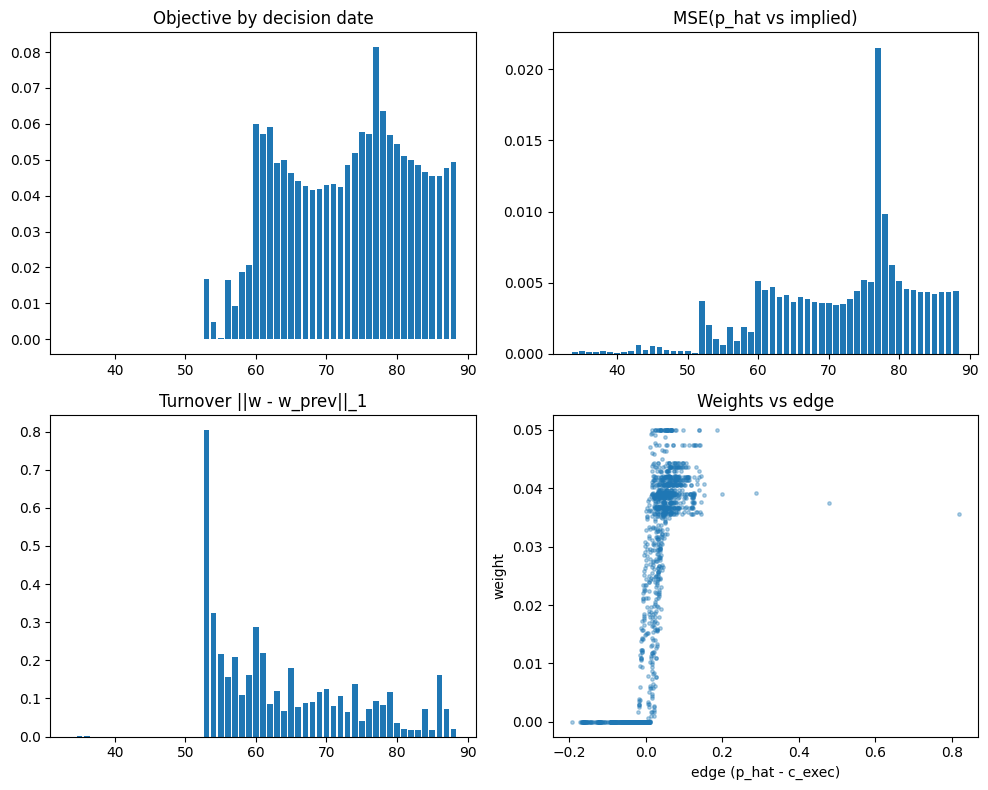

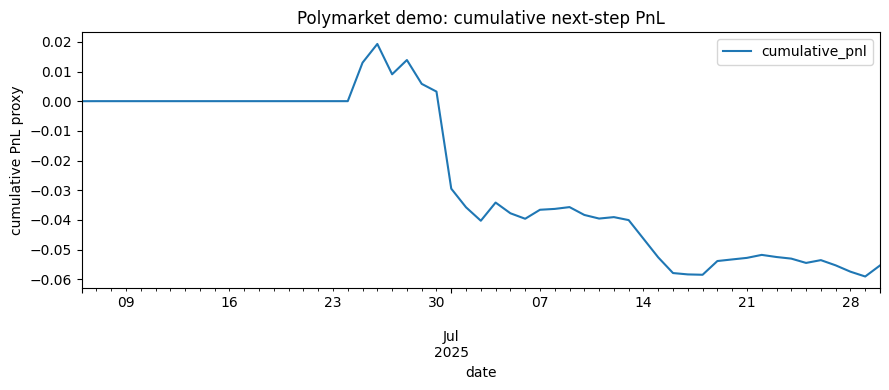

,gross_weight,max_contract_weight,n_positions,mean_edge
count,55.0000,55.0000,55.0000,55.0000
mean,0.6205,0.0275,17.8909,0.0114
std,0.4635,0.0205,13.1497,0.0208
min,0.0000,0.0000,0.0000,-0.0476
25%,0.0000,0.0000,0.0000,-0.0058
50%,1.0000,0.0385,26.0000,0.0177
75%,1.0000,0.0419,28.0000,0.0251
max,1.0000,0.0500,30.0000,0.0506


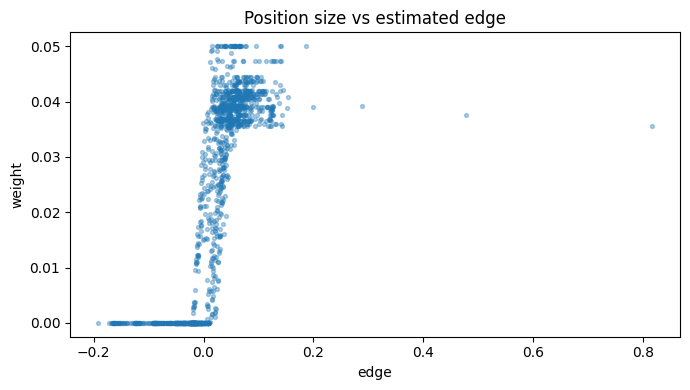

,date,id,weight,p_hat,c_exec,implied,next_implied,edge
93,2025-06-25 00:00:00+00:00,553828,0.05,0.24476,0.180,0.180,0.205,0.06476
98,2025-06-25 00:00:00+00:00,553838,0.05,0.24773,0.180,0.180,0.205,0.06773
96,2025-06-25 00:00:00+00:00,553831,0.05,0.22777,0.170,0.170,0.205,0.05777
108,2025-06-25 00:00:00+00:00,553858,0.05,0.21120,0.115,0.115,0.115,0.09620
110,2025-06-25 00:00:00+00:00,553860,0.05,0.18313,0.105,0.105,0.130,0.07813
115,2025-06-25 00:00:00+00:00,553866,0.05,0.22595,0.170,0.170,0.135,0.05595
141,2025-06-26 00:00:00+00:00,553858,0.05,0.19018,0.115,0.115,0.115,0.07518
94,2025-06-25 00:00:00+00:00,553829,0.05,0.22829,0.165,0.165,0.205,0.06329
95,2025-06-25 00:00:00+00:00,553830,0.05,0.23608,0.170,0.170,0.200,0.06608
143,2025-06-26 00:00:00+00:00,553860,0.05,0.16672,0.130,0.130,0.130,0.03672


In [ ]:

plot_mispricing_diagnostics(poly_result)

if len(pnl):
    pnl_plot = pnl.copy()
    pnl_plot["date"] = pd.to_datetime(pnl_plot["date"])
    pnl_plot = pnl_plot.sort_values("date")
    pnl_plot["cumulative_pnl"] = pnl_plot["pnl_realized_next_step"].cumsum()
    ax = pnl_plot.plot(x="date", y="cumulative_pnl", figsize=(9, 4), title="Polymarket demo: cumulative next-step PnL")
    ax.set_xlabel("date")
    ax.set_ylabel("cumulative PnL proxy")
    plt.tight_layout()
    plt.show()

if len(weights):
    constraint_summary = weights.groupby("date").agg(
        gross_weight=("weight", "sum"),
        max_contract_weight=("weight", "max"),
        n_positions=("weight", lambda s: int((s > 1e-8).sum())),
        mean_edge=("edge", "mean"),
    )
    display(constraint_summary.describe().round(4))
    ax = weights.plot.scatter(x="edge", y="weight", s=8, alpha=0.35, figsize=(7, 4), title="Position size vs estimated edge")
    plt.tight_layout()
    plt.show()
    top_positions = weights.sort_values("weight", ascending=False).head(10)
    display(top_positions[["date", "id", "weight", "p_hat", "c_exec", "implied", "next_implied", "edge"]].round(5))


## What this standalone demo establishes

The equity section reproduces the dynamic rolling optimizer from the project notebooks using only the S&P 500 monthly CSV. The Polymarket section reproduces the mispricing optimizer using only the daily Polymarket panel CSV, with all reusable code embedded in this notebook.